In [1]:
import pandas as pd
from transform import merge_data
import matplotlib.pyplot as plt
import re
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import json
from datetime import datetime
from sklearn.metrics import classification_report

Так как данные представлены из двух источников и объедением их в одни при помощи нашего метода.<br>
Для чистоты коды я решил вынести метод и логику работы с данными в отдельный файл.
<br>
Так же для ускорения процесса анализа, объединённые данные сохраним в pkl формате для более быстрого доступа к ним в последствии

In [2]:
file_name = merge_data('./data/ga_hits.csv', './data/ga_sessions.csv', on_key='session_id')

Начало работы...
Первый df загружен


c:\Users\User\Desktop\МИФИ\python\lessons\math_mehpi\2_term\hacaton\transform.py:8: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_right = pd.read_csv(df_right_name)


Второй df загружен
Идет merge...
Сохранение...


In [ ]:
df = pd.read_pickle(file_name)

In [4]:
df.head()

,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,...,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,5639623078712724064.1640254056.1640254056,2021-12-23,597864.0,30,event,NaN,sberauto.com/cars?utm_source_initial=google&ut...,quiz,quiz_show,NaN,...,NaN,wvtWRwiRmvPIsSQuXnvd,mobile,Android,Huawei,NaN,360x780,Chrome,Russia,Saint Petersburg
1,5639623078712724064.1640254056.1640254056,2021-12-23,290095.0,12,event,NaN,sberauto.com/cars/all/kia/seltos/20f30855?utm_...,card_web,view_new_card,NaN,...,NaN,wvtWRwiRmvPIsSQuXnvd,mobile,Android,Huawei,NaN,360x780,Chrome,Russia,Saint Petersburg
2,5639623078712724064.1640254056.1640254056,2021-12-23,294857.0,18,event,NaN,sberauto.com/cars/all/volkswagen/tiguan/0208cd...,card_web,view_new_card,NaN,...,NaN,wvtWRwiRmvPIsSQuXnvd,mobile,Android,Huawei,NaN,360x780,Chrome,Russia,Saint Petersburg
3,5639623078712724064.1640254056.1640254056,2021-12-23,295591.0,20,event,NaN,sberauto.com/cars/all/volkswagen/tiguan/0208cd...,card_web,view_new_card,NaN,...,NaN,wvtWRwiRmvPIsSQuXnvd,mobile,Android,Huawei,NaN,360x780,Chrome,Russia,Saint Petersburg
4,5639623078712724064.1640254056.1640254056,2021-12-23,290039.0,8,event,NaN,sberauto.com/cars/all/kia/seltos/20f30855?utm_...,card_web,view_new_card,NaN,...,NaN,wvtWRwiRmvPIsSQuXnvd,mobile,Android,Huawei,NaN,360x780,Chrome,Russia,Saint Petersburg


## EDA

Из первичного обзора данных видно, что у нас практически все признаки имеют категорильный тип. 
<br>
Поэтому к сожалению не получится сделать матрицу корреляции по Пирсону. 
<br>
В ML есть и другие инструменты построения корреляционных матриц вроде: V Крамера и расчет Коэффициента неопределенности. Но в рамках курса мы о них не говорили, и у меня нет опыта работы с ними.<br>
Поэтому будем применять другие подходы к EDA

Во первых посмторим что из себя представляют некоторые категории.
<br>
В рамках знакомства с данными я изучил так практически все, но здесь оставил только некоторые

Посмотрим на типы OS пользователей. Тут не так много групп, все нормально

In [207]:
un = df['device_os'].unique()
print(un)
print(len(un))

['Android' 'Windows' 'iOS' 'Linux' 'Macintosh' '(not set)' 'BlackBerry'
 'Tizen' 'Chrome OS' 'Nokia' 'Firefox OS' 'Samsung' nan 'Windows Phone']
14


Изучим целевую переменную

In [118]:
un = df['event_action'].unique()
print(list(un))
print(len(un))

['quiz_show', 'view_new_card', 'view_more_click', 'search_form_search_btn', 'sap_search_form_cost_to', 'view_card', 'go_to_car_card', 'quiz_start', 'showed_number_ads', 'name_entered', 'user_message', 'typing_in_leasing_chat', 'code_sms_entered_success', 'start_chat', 'click_on_confirm_sms_code', 'phone_auth_success', 'search_form_region', 'click_on_start_chatting', 'surname_entered', 'show_sms_code_input', 'auto_subscription_click', 'show_form_lets_get_acquainted', 'automatic_return_to_chat', 'patronymic_entered', 'search_form_mark_select', 'phone_entered', 'show_phone_input', 'search_form_model_select', 'search_form_search_car_type_select', 'start_auth', 'click_on_get_code', 'sub_view_cars_click', 'sub_landing', 'click_on_subscription', 'listing_ads_sort', 'photos', 'pagination_click', 'search_kpp', 'sub_car_claim_submit_click', 'sub_submit_success', 'search_form_model_multiselec', 'sub_car_claim_click', 'sap_search_form_cost_from', 'go_to_offer', 'sub_offer_click', 'analystlabel', '

Посмотрим на признак <b>hit_page_path</b>. Это url страницы с query параметрами, в которых содержится очень ценная для нас информация, а именно параметр <b>utm_source_initial</b> откуда пользователь к нам попал. 
<br>
Этот признак может быть для нас очень ценным, и быть очень полезным в разделении на группы
<br><br>
Сначала оценим что там есть и будет ли нам это полезно.
Такого рода преобразования я люблю выполнять в виде цепочки функций. Например в JS или C# с LINQ это выглядит очень красиво. К сожаления, хотя python и считается языком с возможность функционального программирования, такого рода конструкции без применения специальных библиотек, выглядят в нем не очень читаемо.

In [6]:
def get_unique_column_list(data_farme, col_name, reg):
    unique_urls = data_farme[col_name].unique()
    utm_source_initial_data = filter(lambda s: s is not None,
                                    map(lambda y: None if y is None else y.group(1) if y else None,
                                                                map(lambda x: re.search(reg, x),list(unique_urls))))
    source_set = set(utm_source_initial_data)
    
    return source_set, len(source_set)

Посмотрим на результат. Пока вполне не плохо. Есть четкие группы

In [10]:
utm_source_data, source_count = get_unique_column_list(df, 'hit_page_path', r'utm_source_initial=([^&]+)')
print(f'Кол-во категорий: {source_count}')
print(utm_source_data)

Кол-во категорий: 62
{'2gis', 'telegram', 'stnd', 'mobile_spasibo', 'imho_videonetwork\\u0026pid=imho_videonetwork\\u0026utm_content_initial=', 'mytarget', 'mediatoday', 'sber', 'sberauto_podbor_fb_di', 'youtube', 'yandex_poisk_web', 'facebook_instagram', 'instagram', 'tiktok', 'zarulem', 'partners', 'targetnative', 'test_source', 'sbol_auto', 'telegr', 'test', 'sberauto', 'roden_media', 'imho_videonetwork', 'vkontakte', 'fb', 'rbc', 'native_roll', 'vk', 'r_email', 'source', 'blog', 'google_poisk_web', 'article', 'google', 'yandex_poisk', 'auto.ru', 'nativerent', 'test777', 'outdoor', 'mail_main', 'email_spasibo', 'rambler', '123', 'yandex_main', 'ixbtcom', 'rodenmedia', 'email', 'allboxes.ru', 'yandex', 'sbol', 'dzen', 'facebook', 'imho_video', 'outlook', 'blogger', 'google_poisk', 'tt', 'display_premium_network', 'programmatica', 'gpmd', 'yandex.zen'}


Посмотрим на другой потенциальный query параметр rental_page.<br>
Как видим, тут нет ничего осмысленного и работать дальше не с чем

In [11]:
utm_rental_data, rental_count = get_unique_column_list(df, 'hit_page_path', r'rental_page=([^&]+)')
print(f'Кол-во категорий: {rental_count}')
print(utm_rental_data)

Кол-во категорий: 27
{'rental_car?utm_source=rbc', 'rental_car#utm_source=facebook', 'rental_car#no_mobile', 'rental_car?utm_source=test_source', 'rental_car0', 'rental_car.', 'rental_car/', 'rental_only', 'rental_car?utm_source=mediatoday', 'rental_carbf24b977?utm_source=outlook', 'rental_only#no_mobile', 'rental_car', 'rental', 'rental_car#utm_source=google', 'rental_car#utm_source=vkontakte', 'rental_car611042', 'rental_car?utm_source=yandex', 'rental_car000', 'rental_carm/cars/95eb25d5?utm_source=outlook', 'rental_car+', 'rental_car#no', 'rental_car\\', 'rental_car )', 'rental_car ', 'rental_carutm_source=yandex', "rental_car'", 'rental_car?abtest=1'}


Тогда создадим новый признак <b>utm_source_initial</b>. Применим тоже регулярное выражение к каждому значению через apply

In [3]:
def create_utm_source_initial(url):
    if url is None:
        return None
    reg = re.search(r'utm_source_initial=([^&]+)', url)
    return reg.group(1) if reg else None

df['utm_source_initial'] = df['hit_page_path'].apply(create_utm_source_initial)

Так же создадим новый признак <b>direct_cat_link</b> на основе части маршрута "<b>/cars/all/</b>" который видет к странице конкретной машины.
<br>
Это может говорить о том, что пользователь уже имеет предпочтения по марке автомобиля и знает что хочет.

In [ ]:
df['direct_cat_link'] = df['hit_page_path'].str.contains(r'/cars/all/', regex=True)

Исходный признак удалим

In [5]:
df.drop(columns=['hit_page_path'], inplace=True)

Далее попробуем восстановить пустые значения для некоторых признаков device_os. Создадим map с парами ключ-значение, где с точной уверенность можем сопоставить марку устройства с его OC.

In [6]:
df['device_os_filled'] = df['device_os'].fillna(
    df['device_brand'].map({'Apple': 'iOS', 'Samsung': 'Android', 'Xiaomi': 'Android', 'Google':'Android'})
)

Теперь посмотрим на признаки которые точно нужно удалить
<br>
Для удобства выведем список со всеми признаками

In [6]:
print(df.columns.to_list())

['session_id', 'hit_date', 'hit_time', 'hit_number', 'hit_type', 'hit_referer', 'hit_page_path', 'event_category', 'event_action', 'event_label', 'event_value', 'client_id', 'visit_date', 'visit_time', 'visit_number', 'utm_source', 'utm_medium', 'utm_campaign', 'utm_adcontent', 'utm_keyword', 'device_category', 'device_os', 'device_brand', 'device_model', 'device_screen_resolution', 'device_browser', 'geo_country', 'geo_city']


Проверим, что это одно и то же

In [7]:
(df['visit_date'] == df['hit_date']).unique()

array([ True])

В итоге я решил удалить эти признаки:
<br><br>
session_id, client_id, hit_number, event_label, utm_keyword, hit_referer - служебная информация
<br>
device_screen_resolution - считаю излишним так как есть много из других признаков об устройстве пользователя
<br>
device_os - создали производный признак device_os_filled
<br>
hit_date - дублирует visit_date

In [8]:
for_delete = ['session_id', 'client_id', 'hit_date', 'visit_number', 'utm_keyword', 'hit_number', 'hit_referer', 'event_label', 'event_value', 'device_screen_resolution', 'device_os']

df.drop(columns=for_delete, inplace=True)

In [9]:
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 15685219 entries, 0 to 15685218
Data columns (total 19 columns):
 #   Column              Non-Null Count     Dtype  
---  ------              --------------     -----  
 0   hit_time            6525016 non-null   float64
 1   hit_type            15685219 non-null  object 
 2   event_category      15685219 non-null  object 
 3   event_action        15685219 non-null  object 
 4   visit_date          15685219 non-null  object 
 5   visit_time          15685219 non-null  object 
 6   utm_source          15684519 non-null  object 
 7   utm_medium          15685219 non-null  object 
 8   utm_campaign        13486346 non-null  object 
 9   utm_adcontent       12852801 non-null  object 
 10  device_category     15685219 non-null  object 
 11  device_brand        11739344 non-null  object 
 12  device_model        122287 non-null    object 
 13  device_browser      15685219 non-null  object 
 14  geo_country         15685219 non-null  object 
 

In [215]:
df.isnull().mean() 

hit_time              0.584002
hit_type              0.000000
event_category        0.000000
event_action          0.000000
visit_time            0.000000
utm_source            0.000045
utm_medium            0.000000
utm_campaign          0.140188
utm_adcontent         0.180579
device_category       0.000000
device_brand          0.251566
device_model          0.992204
device_browser        0.000000
geo_country           0.000000
geo_city              0.000000
utm_source_initial    0.620545
device_os_filled      0.240656
dtype: float64

Как видим в <b>hit_time и device_model</b> очень много пропусков. 
<br>
Так же мне непонятен формат <b>hit_time</b>, в реальной задаче была бы необходима консультация со специалистами кто занимается метриками 

In [10]:
df.drop(columns=['hit_time', 'device_model'], inplace=True)

Далее, воспользуемся признаком <b>visit_time</b>. Выделим из него категорию, которая будет показывать время суток. 
<br>
Разделим на: ночь, утро, первая половина дня, вторая половина дня, вечер, поздний вечер

In [11]:
df['hour'] = pd.to_datetime(df['visit_time'], format='%H:%M:%S').dt.hour

df['day_part'] = pd.cut(
    df['hour'],
    bins=[0, 7, 10, 14, 18, 22, 24],
    labels=['night', 'morning', 'day', 'afternoon', 'evening', 'l_evening'],
    right=False
)

Далее, выделим из признака <b>visit_date</b> категорию выходной день или нет

In [14]:
df['visit_date'] = pd.to_datetime(df['visit_date'])
df['is_weekend'] = df['visit_date'].dt.dayofweek.isin([5, 6]).astype(str)

Удалим исходные признаки

In [15]:
df.drop(columns=['hour', 'visit_time', 'visit_date'], inplace=True)

In [16]:
df.isnull().mean().round(2)

hit_type              0.00
event_category        0.00
event_action          0.00
utm_source            0.00
utm_medium            0.00
utm_campaign          0.14
utm_adcontent         0.18
device_category       0.00
device_brand          0.25
device_browser        0.00
geo_country           0.00
geo_city              0.00
utm_source_initial    0.62
direct_cat_link       0.00
device_os_filled      0.24
day_part              0.00
is_weekend            0.00
dtype: float64

В исходных данных есть все возможные типы событий. Проведя исследования уникальных значений <b>event_action</b>, я выделил часть, которая полагаю, хорошо определяет целевое действие - конверсию пользователя на сайте.

In [17]:
target_events = [
    'sub_submit_success',   
    'sub_car_claim_submit_click',       
    'sub_car_request_submit_click',     
    'sub_custom_question_submit_click', 
    'sub_callback_submit_click',
    'callback_requested',
    'form_request_call_sent',
    'callback button',
    'click_on_request_call',
    'sub_call_number_click',
    'tap_on_phone_800',
    'tap_on_phone_495',
    'mobile call',
    'sub_open_dialog_click',
    'chat established',
    'client initiate chat',
    'user_message',
    'user gave contacts during chat',
    'click_pos_credit',
    'click_credit',
    'click_on_credit_btn',
    'auto_subscription_click',
    'click_auto_subscription',
    'click_on_subscription',
    'sub_offer_click',
    'sub_banner_click',
]

На их основе создадим целевой признак

In [33]:
df['target'] = df['event_action'].isin(target_events).astype(int)

In [34]:
df.drop(columns=['event_action'], inplace=True)

In [124]:
df.isnull().mean().round(2)

hit_type              0.00
event_category        0.00
utm_source            0.00
utm_medium            0.00
utm_campaign          0.14
utm_adcontent         0.18
device_category       0.00
device_os             0.58
device_brand          0.25
device_browser        0.00
geo_country           0.00
geo_city              0.00
device_os_filled      0.17
day_part              0.00
utm_source_initial    0.62
target                0.00
dtype: float64

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 15685219 entries, 0 to 15685218
Data columns (total 17 columns):
 #   Column              Dtype   
---  ------              -----   
 0   hit_type            object  
 1   event_category      object  
 2   event_action        object  
 3   utm_source          object  
 4   utm_medium          object  
 5   utm_campaign        object  
 6   utm_adcontent       object  
 7   device_category     object  
 8   device_brand        object  
 9   device_browser      object  
 10  geo_country         object  
 11  geo_city            object  
 12  utm_source_initial  object  
 13  direct_cat_link     bool    
 14  device_os_filled    object  
 15  day_part            category
 16  is_weekend          object  
dtypes: bool(1), category(1), object(15)
memory usage: 1.9+ GB


## Выбор алгоритма CatBoost

В нашем случае у нас все признаки имею категориальный тип. Поэтому идеальным вариантом считаю <b>CatBoost от Yandex</b>.
<br>
Данный алгоритм как раз был разработан для эффективного кодирования категориальных признаков. Из плюсов он умеет кодировать признаки с большим количеством категорий. Как мы увидим в дальнейшем нам это пригодится.
<br>
В качестве core ядра он использует градиентный бустинг на деревьях решений. Деревья расположены друг за другом и последовательно улучшают работу предыдущих. 
<br>
Чем то это похоже на работу нейросети, только в качестве слоев с нейронами у нас графы с деревьями.

Для CatBoost важно что бы все категории были типа string поэтому конвертируем наши ранее созданные признаки

In [19]:
df['day_part'] = df['day_part'].astype(object)
df['direct_cat_link'] = df['direct_cat_link'].astype(object)

Так же выделим None в отдельную категорию Nan, т.к CatBoost не умеет напрямую работать с None

In [20]:
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna('NaN').astype(str)

## Предыдущие исследования

Данный ноутбук представляет собой чистовой вариант обработки и обучения моделей. До этого было проделано много работы по исследованию данных и попыток обучения моделей. 
<br>
Далее представлен график значимости признаков от данных CatBoost, в одной из исследовательских итераций.
<br>
Как видми <b>geo_country и geo_city</b> практически не вносят свой вклад в предсказания модели, хотя сначала казалось логичным что страна и город могут как то влиять на возможности пользователя воспользоваться услугой.
<br>
Поэтому считаю целесообразно из удалить

In [23]:
df.drop(columns=['geo_country', 'geo_city'], inplace=True)

Так же в результате предыдущих исследований я выяснил что <b>event_category и hit_type</b> ведут к переобучению модели, т.к. с ними метрика ROc-AUC была примерно равна 0.98, что не может быть правдной на реальных данных.

In [21]:
df.drop(columns=['event_category', 'hit_type'], inplace=True)

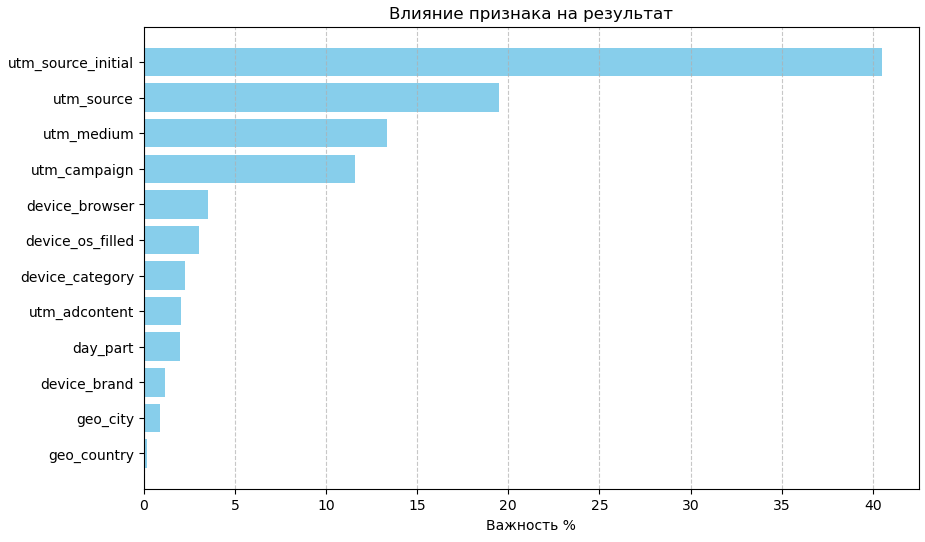

Так же видим что <b>utm_source</b> и <b>utm_campaign</b> важные признаки.  
<br>
Из описания данных это:
<br>
<b>utm_source</b> - канал привлечения
<br>
<b>utm_campaign</b> - рекламная компания
<br><br>
Возможно это какие-то ключи из БД или хеш значения. 
<br>
В реальном проекте нужна консультация со смежными специалистами.
<br>
utm_source очень похож по смыслу на наш сгенерированный признак utm_source_initial.
<br><br>
И тут нас выручает <b>CatBoost</b>, который хорошо справляется даже с таким количеством категорий.
<br><br>
В итоге я решил оставить все эти признаки.

In [354]:
utm_source_data = df['utm_source'].unique()

print(utm_source_data[:10])
print(len(utm_source_data))

['kjsLglQLzykiRbcDiGcD' 'ZpYIoDJMcFzVoPFsHGJL' 'BHcvLfOaCWvWTykYqHVe'
 'fDLlAcSmythWSCVMvqvL' 'MvfHsxITijuriZxsqZqt' 'vFcAhRxLfOWKhvxjELkx'
 'QxAxdyPLuQMEcrdZWdWb' 'IZEXUFLARCUMynmHNBGo' 'iNFgfQPqHPBuvGCYtrQE'
 'GpAkIXsclxDGyILfNlrR']
281


In [355]:
utm_campaign_data = df['utm_campaign'].unique()

print(utm_campaign_data[:10])
print(len(utm_campaign_data))

['NaN' 'zxoiLxhuSIFrCeTLQVWZ' 'LTuZkdKfxRGVceoWkVyg'
 'FTjNLDyTrXaWYgZymFkV' 'LEoPHuyFvzoNfnzGgfcd' 'okTXSMadDkjvntEHzIjp'
 'mSVMBvlHFgftJaQAZEdp' 'foFTSdUvNqqkPzZvgiqt' 'HtyIDWOBgqXsGucSiffW'
 'GWZGdHKPgmZPNPwkJshU']
407


## Рефакторинг созданных нами признаков

Далее, в процессе улучшения признакового пространства модели я обратил внимание что <b>utm_source_initial</b> содержит много дублирующих по смыслу категорий и их можно логически объединить.

In [22]:
df['utm_source_initial'].unique()

array(['google', 'sbol', 'yandex', 'NaN', 'youtube', 'dzen', 'telegram',
       'facebook', 'google_poisk', 'yandex_poisk', 'sber',
       'google_poisk_web', 'outlook', 'test', 'gpmd', 'auto.ru',
       'test_source', '123', 'vkontakte', 'instagram', 'email',
       'yandex_poisk_web', 'blogger', 'imho_video', 'sberauto',
       'email_spasibo', 'fb', 'vk', 'yandex_main', 'allboxes.ru',
       'sbol_auto', 'mytarget', 'mobile_spasibo', 'facebook_instagram',
       'ixbtcom', 'telegr', 'rambler', 'partners', 'tt', 'roden_media',
       'tiktok', 'nativerent', 'r_email', 'rodenmedia', 'test777',
       'imho_videonetwork', 'yandex.zen', 'outdoor',
       'sberauto_podbor_fb_di', 'rbc', 'mediatoday', '2gis', 'mail_main',
       'targetnative',
       'imho_videonetwork\\u0026pid=imho_videonetwork\\u0026utm_content_initial=',
       'display_premium_network', 'source', 'native_roll', 'blog',
       'article', 'stnd', 'zarulem', 'programmatica'], dtype=object)

In [24]:
len(df[df['utm_source_initial'] == 'imho_videonetwork\\u0026pid=imho_videonetwork\\u0026utm_content_initial='])

6

Создадим карту для объединения признаков, редкие и непонятные признаки объединим в категорию other

In [25]:
source_mapping = {
            'yandex_main': 'yandex', 'yandex_poisk_web': 'yandex', 'yandex_poisk': 'yandex', 'yandex.zen': 'yandex',
            'google_poisk_web': 'google', 'google_poisk': 'google',
            'fb': 'facebook', 'facebook_instagram': 'facebook',
            'sbol': 'sber', 'sbol_auto': 'sber', 'sberauto': 'sber', 'mobile_spasibo': 'sber', 'email_spasibo': 'sber', 'sberauto_podbor_fb_di': 'sber',
            'telegr': 'telegram',
            'tt': 'tiktok',
            'r_email': 'email',
            'test': 'other', 'test_source': 'other', 'test777': 'other', '123': 'other', 'source': 'other', 'nan': 'other', 'imho_videonetwork\\u0026pid=imho_videonetwork\\u0026utm_content_initial=':'other'
        }

In [26]:
df['utm_source_initial'] = df['utm_source_initial'].replace(source_mapping)

То же самое сделаем с <b>utm_medium</b>

In [27]:
df['utm_medium'].unique()

array(['cpc', 'banner', '(none)', 'cpm', 'organic', 'cpa',
       'blogger_channel', 'push', 'referral', 'email', 'outlook', 'smm',
       'smartbanner', 'sms', 'tg', 'info_text', 'clicks', '(not set)',
       'partner', 'nkp', 'post', 'yandex_cpc', 'landing', 'CPM', 'cpv',
       'ok_smm', 'app', 'link', 'article', 'vk_smm', 'web_polka',
       'blogger_stories', 'landing_interests', 'Sbol_catalog',
       'dom_click', 'users_msk', 'medium', 'static', 'fb_smm',
       'main_polka', 'google_cpc', 'linktest', 'qr', 'promo_sber',
       'promo_sbol', 'stories', 'social', 'last', 'qrcodevideo',
       'catalogue', 'sber_app', 'blogger_header', 'cbaafe', 'reach',
       'tablet'], dtype=object)

In [28]:
utm_medium_map = {
    'web_polka':'polka', 'main_polka':'polka',
    'Sbol_catalog':'sber', 'promo_sbol':'sber', 'sber_app':'sber', 'promo_sber':'sber',
    'vk_smm':'smm', 'ok_smm':'smm', 'fb_smm':'smm', 'yandex_cpc':'cpc', 'google_cpc':'cpc',
    'blogger_header':'blogger', 'blogger_stories':'blogger', 'blogger_channel':'blogger',
    'cbaafe':'other','(none)':'other','(not set)':'other','last':'other','linktest':'other',
    'outlook':'email',
    'qrcodevideo':'qr',
    'smartbanner':'banner'
}

In [29]:
df['utm_medium'] = df['utm_medium'].replace(utm_medium_map)

Так же видим что есть одинаковые категории в разных регистрах. Приведем все к нижнему регистру.

In [30]:
df['utm_medium'] = df['utm_medium'].str.lower()

Стало лучше

In [31]:
df['utm_medium'].unique()

array(['cpc', 'banner', 'other', 'cpm', 'organic', 'cpa', 'blogger',
       'push', 'referral', 'email', 'smm', 'sms', 'tg', 'info_text',
       'clicks', 'partner', 'nkp', 'post', 'landing', 'cpv', 'app',
       'link', 'article', 'polka', 'landing_interests', 'sber',
       'dom_click', 'users_msk', 'medium', 'static', 'qr', 'stories',
       'social', 'catalogue', 'reach', 'tablet'], dtype=object)

## Распределение классов

Посмотрим на количественное распределение классов в нашем датасете.
<br>
Видим очень сильный дисбаланс. Даже для встроенного балансировщика CatBoost это очень большое значения.

In [35]:
print(f"0 - {len(df[df['target'] == 0])}")
print(f"1 - {len(df[df['target'] == 1])}")

0 - 15519024
1 - 166195


Для начала воспользуемся ручной балансировкой. 
<br>
Для этого случайным образом возьмем 500000 строк из класса 0 и объединим в новый дата фрейм со всеми классами 1. Затем перемешаем все строки.

In [36]:
df_ones = df[df['target'] == 1] 
df_zeros = df[df['target'] == 0]

In [37]:
df_zeros_sampled = df_zeros.sample(n=500000, random_state=42)
df_balanced = pd.concat([df_ones, df_zeros_sampled])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

Стало уже лучше. остальное оставим auto_class_weights от CatBoost

In [38]:
print(f"0 - {len(df_balanced[df_balanced['target'] == 0])}")
print(f"1 - {len(df_balanced[df_balanced['target'] == 1])}")

0 - 500000
1 - 166195


In [39]:
X_balanced = df_balanced.drop(columns=['target'])
y_balanced = df_balanced['target']

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, 
    test_size=0.3, 
    random_state=42, 
    stratify=y_balanced
)

Обучим модель CatBoostClassifier. Попробовав несколько разных итераций на разных гиперпараметрах, я нашел самые подходящие:

In [ ]:
cat_features = list(X_balanced.select_dtypes(include=['object']).columns)

model_cleaned_balanced = CatBoostClassifier(
    iterations=200,
    learning_rate=0.05,
    depth=8,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    thread_count=-1,
    cat_features=cat_features,
    max_ctr_complexity=1,
    early_stopping_rounds=50,
    verbose=1,
    auto_class_weights='Balanced',
)

model_cleaned_balanced.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    verbose=1,
)

y_pred_proba_balanced = model_cleaned_balanced.predict_proba(X_test)[:, 1]

roc_auc_cleaned = roc_auc_score(y_test, y_pred_proba_balanced)
print(f"ROC-AUC: {roc_auc_cleaned:.4f}")

0:	test: 0.6205906	best: 0.6205906 (0)	total: 378ms	remaining: 1m 15s
1:	test: 0.6219743	best: 0.6219743 (1)	total: 609ms	remaining: 1m
2:	test: 0.6249128	best: 0.6249128 (2)	total: 855ms	remaining: 56.2s
3:	test: 0.6249489	best: 0.6249489 (3)	total: 1.07s	remaining: 52.3s
4:	test: 0.6254583	best: 0.6254583 (4)	total: 1.29s	remaining: 50.3s
5:	test: 0.6335325	best: 0.6335325 (5)	total: 1.52s	remaining: 49s
6:	test: 0.6371968	best: 0.6371968 (6)	total: 1.73s	remaining: 47.7s
7:	test: 0.6381977	best: 0.6381977 (7)	total: 1.94s	remaining: 46.5s
8:	test: 0.6386713	best: 0.6386713 (8)	total: 2.17s	remaining: 46s
9:	test: 0.6391109	best: 0.6391109 (9)	total: 2.38s	remaining: 45.1s
10:	test: 0.6394967	best: 0.6394967 (10)	total: 2.59s	remaining: 44.5s
11:	test: 0.6445543	best: 0.6445543 (11)	total: 2.82s	remaining: 44.2s
12:	test: 0.6462731	best: 0.6462731 (12)	total: 3.06s	remaining: 44s
13:	test: 0.6475864	best: 0.6475864 (13)	total: 3.31s	remaining: 44s
14:	test: 0.6494739	best: 0.6494739 

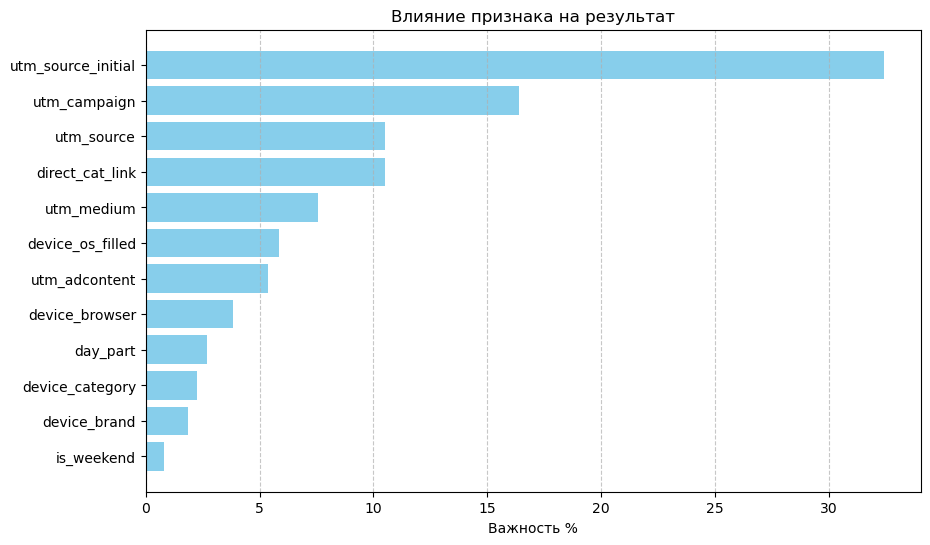

In [42]:
feature_importance = model_cleaned_balanced.get_feature_importance()
feature_names = X_train.columns

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(df_importance['Feature'], df_importance['Importance'], color='skyblue')
plt.xlabel('Важность %')
plt.title('Влияние признака на результат')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
y_pred_standard = model_cleaned_balanced.predict(X_test)
print(classification_report(y_test, y_pred_standard))

              precision    recall  f1-score   support

           0       0.84      0.62      0.72    150000
           1       0.36      0.65      0.47     49859

    accuracy                           0.63    199859
   macro avg       0.60      0.64      0.59    199859
weighted avg       0.72      0.63      0.65    199859



Модель способна в 69% случаев отличить пользователя, который совершит целевое действие, от того, кто не совершит.
<br>
Так же видно, что у класса 1 precision  = 0.36, т.е точность предсказания действия которое принесет конверсию невелико.  
<br>
При этом recall для класса 1 равен 0.65, т.е. модель находит 65% всех реальных объектов этого класса.
<br><br>
Я считаю для такого сильного исходного дисбаланса классов это неплохо и для такого уровня задачи это может быть неплохим инструментом для бизнеса.

Сохраним модель

In [44]:
model_cleaned_balanced.save_model('./models/conversion_model.cbm')

Так же сохраним в json информацию о модели, что бы потом её использовать в нашем api проекте. 
<br>
Пусть это будет некое подобие A2A карточки агента, только карточка модели.

In [46]:
model_info = {
    'author':'Obozov Andrey',
    'feature_names': list(X_train.columns),
    'cat_features': cat_features,
    'target_name': 'event_action',
    'target_events_list':list(target_events),
    'training_date': datetime.now().isoformat(),
    'roc_auc': round(model_cleaned_balanced.best_score_['validation']['AUC'], 2)
}

with open('./models/conversion_model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)